In [1]:
# ============================================================
# 1. INSTALLATION
# ============================================================
!pip -q install scipy scikit-learn matplotlib seaborn pandas joblib nibabel

import sys, os, random, math, json, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import ndimage
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, confusion_matrix
)
from sklearn.inspection import permutation_importance
import joblib

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Python: 3.13.15
PyTorch: 2.11.0+cu130
CUDA available: True
GPU: Tesla T4
Using device: cuda


In [2]:
# ============================================================
# 2. PROJECT CONFIGURATION
# ============================================================
DEMO_MODE = True

# Synthetic demo size. Keep these modest for a quick showcase.
VOLUME_SHAPE = (48, 64, 64)   # D, H, W
N_SAMPLES = 100
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15

BATCH_SIZE = 2
EPOCHS = 8
LEARNING_RATE = 2e-3

ARTIFACT_DIR = "/content/knee_oa_demo_artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

print("Mode:", "DEMO / SYNTHETIC" if DEMO_MODE else "REAL DATA")
print("Artifacts:", ARTIFACT_DIR)

Mode: DEMO / SYNTHETIC
Artifacts: /content/knee_oa_demo_artifacts


In [3]:
# ============================================================
# 3. SYNTHETIC 3D KNEE MRI GENERATOR
# ============================================================
def make_ellipsoid(shape, center, radii):
    z, y, x = np.indices(shape)
    cz, cy, cx = center
    rz, ry, rx = radii
    return (((z-cz)/rz)**2 + ((y-cy)/ry)**2 + ((x-cx)/rx)**2) <= 1.0

def normalize01(a):
    a = a.astype(np.float32)
    lo, hi = np.percentile(a, [1, 99])
    a = np.clip((a - lo) / (hi - lo + 1e-8), 0, 1)
    return a.astype(np.float32)

def generate_synthetic_case(shape=VOLUME_SHAPE, seed=0):
    rng = np.random.default_rng(seed)
    D, H, W = shape

    severity = float(rng.uniform(0.0, 1.0))

    # Bone geometry.
    femur = make_ellipsoid(
        shape,
        center=(int(D*0.43), H//2, W//2),
        radii=(int(D*0.19), int(H*0.30), int(W*0.32))
    )
    tibia = make_ellipsoid(
        shape,
        center=(int(D*0.72), H//2, W//2),
        radii=(int(D*0.12), int(H*0.34), int(W*0.34))
    )

    # Cartoon-like cartilage shell. Severity reduces shell thickness.
    shell_width = max(1, int(round(4 - 3*severity)))
    dilated_f = ndimage.binary_dilation(femur, iterations=shell_width)
    dilated_t = ndimage.binary_dilation(tibia, iterations=shell_width)

    # Keep mainly the facing surfaces near the joint.
    joint_window = np.zeros(shape, dtype=bool)
    joint_window[int(D*0.53):int(D*0.69)] = True

    cartilage = ((dilated_f & ~femur) | (dilated_t & ~tibia)) & joint_window

    # Add a localized defect whose size grows with severity.
    defect_mask = make_ellipsoid(
        shape,
        center=(int(D*(0.61 + 0.02*rng.normal())), int(H*0.52), int(W*0.50)),
        radii=(
            max(1, int(1 + 5*severity)),
            max(1, int(2 + 4*severity)),
            max(1, int(3 + 5*severity))
        )
    )
    defect_mask &= cartilage
    cartilage = cartilage & ~defect_mask

    # MRI-like signal.
    img = np.full(shape, 0.06, dtype=np.float32)

    # Fluid/background contrast.
    fluid = ndimage.gaussian_filter(
        rng.normal(0, 0.08, size=shape).astype(np.float32),
        sigma=1.0
    )
    img += fluid

    img[femur] += 0.28
    img[tibia] += 0.24
    img[cartilage] += 0.43
    img[defect_mask] -= 0.22

    # Joint fluid band.
    joint_fluid = make_ellipsoid(
        shape,
        center=(int(D*0.61), H//2, W//2),
        radii=(max(2, int(D*0.065)), int(H*0.22), int(W*0.24))
    )
    img[joint_fluid] += 0.20

    img += rng.normal(0, 0.035, size=shape).astype(np.float32)
    img = ndimage.gaussian_filter(img, sigma=0.6)
    img = normalize01(img)

    # Synthetic demographic covariates with a weak severity relationship.
    age = float(np.clip(45 + 30*rng.random() + 7*severity + rng.normal(0, 2), 45, 80))
    bmi = float(np.clip(21.5 + 11*rng.random() + 3*severity + rng.normal(0, 1), 20, 38))

    # Synthetic continuous target ONLY for demonstration.
    # It is deliberately not a validated OA score.
    synthetic_score = float(np.clip(
        4.0*severity + 0.06*(bmi-25) + rng.normal(0, 0.20),
        0, 4
    ))

    synthetic_grade = int(np.digitize(
        synthetic_score,
        bins=[0.8, 1.6, 2.4, 3.2]
    ))

    return {
        "image": img.astype(np.float32),
        "mask": cartilage.astype(np.uint8),
        "defect_mask": defect_mask.astype(np.uint8),
        "age": age,
        "bmi": bmi,
        "synthetic_score": synthetic_score,
        "synthetic_grade": synthetic_grade,
        "severity": severity
    }

cases = [generate_synthetic_case(seed=SEED+i) for i in range(N_SAMPLES)]

print("Generated cases:", len(cases))
print("Volume shape:", cases[0]["image"].shape)
print("Example age/BMI:", round(cases[0]["age"],1), round(cases[0]["bmi"],1))
print("Example demo target:", round(cases[0]["synthetic_score"],2))

Generated cases: 100
Volume shape: (48, 64, 64)
Example age/BMI: 71.4 25.4
Example demo target: 2.68


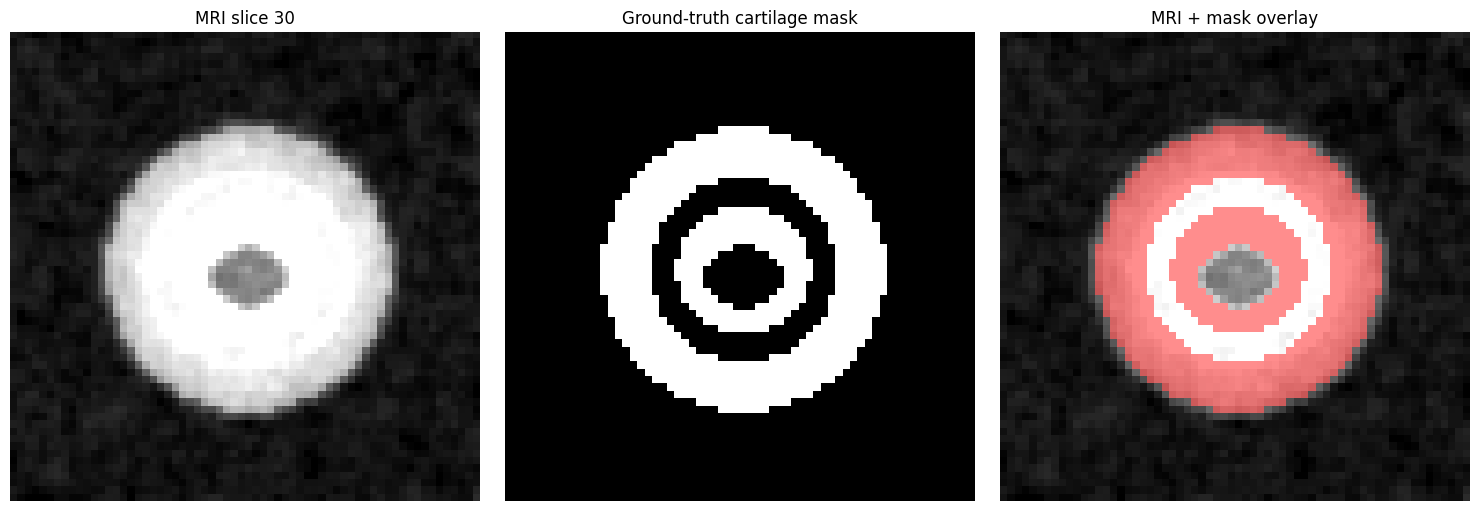

In [4]:
# ============================================================
# 4. VISUALIZE ONE 3D CASE
# ============================================================
def show_case(case, slice_idx=None):
    img = case["image"]
    mask = case["mask"]

    if slice_idx is None:
        # Choose the slice with the largest mask area.
        areas = mask.sum(axis=(1,2))
        slice_idx = int(np.argmax(areas))

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(img[slice_idx], cmap="gray")
    axes[0].set_title(f"MRI slice {slice_idx}")
    axes[0].axis("off")

    axes[1].imshow(mask[slice_idx], cmap="gray")
    axes[1].set_title("Ground-truth cartilage mask")
    axes[1].axis("off")

    axes[2].imshow(img[slice_idx], cmap="gray")
    axes[2].imshow(np.ma.masked_where(mask[slice_idx] == 0, mask[slice_idx]),
                   alpha=0.45, cmap="autumn")
    axes[2].set_title("MRI + mask overlay")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

show_case(cases[0])

In [5]:
# ============================================================
# 5. TRAIN / VALIDATION / TEST SPLIT
# ============================================================
indices = np.arange(N_SAMPLES)
rng = np.random.default_rng(SEED)
rng.shuffle(indices)

n_train = int(N_SAMPLES * TRAIN_FRAC)
n_val = int(N_SAMPLES * VAL_FRAC)

train_ids = indices[:n_train]
val_ids = indices[n_train:n_train+n_val]
test_ids = indices[n_train+n_val:]

print("Train:", len(train_ids))
print("Validation:", len(val_ids))
print("Test:", len(test_ids))

assert len(set(train_ids) & set(val_ids)) == 0
assert len(set(train_ids) & set(test_ids)) == 0
assert len(set(val_ids) & set(test_ids)) == 0

Train: 70
Validation: 15
Test: 15


In [6]:
# ============================================================
# 6. DATASET + 3D U-NET
# ============================================================
class SyntheticSegDataset(Dataset):
    def __init__(self, cases, ids):
        self.cases = cases
        self.ids = list(ids)

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        c = self.cases[self.ids[idx]]
        x = torch.from_numpy(c["image"][None, ...])
        y = torch.from_numpy(c["mask"][None, ...].astype(np.float32))
        return x, y

train_loader = DataLoader(
    SyntheticSegDataset(cases, train_ids),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=0
)
val_loader = DataLoader(
    SyntheticSegDataset(cases, val_ids),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)
test_loader = DataLoader(
    SyntheticSegDataset(cases, test_ids),
    batch_size=1, shuffle=False, num_workers=0
)

class DoubleConv3D(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

class Tiny3DUNet(nn.Module):
    def __init__(self, base=8):
        super().__init__()
        self.enc1 = DoubleConv3D(1, base)
        self.enc2 = DoubleConv3D(base, base*2)
        self.bottleneck = DoubleConv3D(base*2, base*4)

        self.pool = nn.MaxPool3d(2)
        self.up2 = nn.ConvTranspose3d(base*4, base*2, 2, stride=2)
        self.dec2 = DoubleConv3D(base*4, base*2)
        self.up1 = nn.ConvTranspose3d(base*2, base, 2, stride=2)
        self.dec1 = DoubleConv3D(base*2, base)

        self.out = nn.Conv3d(base, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        b = self.bottleneck(self.pool(e2))

        d2 = self.up2(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out(d1)

model = Tiny3DUNet(base=8).to(DEVICE)
print(model)
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Tiny3DUNet(
  (enc1): DoubleConv3D(
    (block): Sequential(
      (0): Conv3d(1, 8, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
      (1): BatchNorm3d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv3d(8, 8, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
      (4): BatchNorm3d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc2): DoubleConv3D(
    (block): Sequential(
      (0): Conv3d(8, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
      (1): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
      (4): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
 

In [7]:
# ============================================================
# 7. SEGMENTATION LOSS + METRICS
# ============================================================
def dice_score_from_logits(logits, target, eps=1e-6):
    prob = torch.sigmoid(logits)
    pred = (prob > 0.5).float()

    inter = (pred * target).sum(dim=(1,2,3,4))
    denom = pred.sum(dim=(1,2,3,4)) + target.sum(dim=(1,2,3,4))
    dice = (2*inter + eps) / (denom + eps)
    return dice.mean()

def dice_loss(logits, target):
    prob = torch.sigmoid(logits)
    inter = (prob * target).sum(dim=(1,2,3,4))
    denom = prob.sum(dim=(1,2,3,4)) + target.sum(dim=(1,2,3,4))
    dice = (2*inter + 1e-6) / (denom + 1e-6)
    return 1 - dice.mean()

bce = nn.BCEWithLogitsLoss()

def segmentation_loss(logits, target):
    return 0.5 * bce(logits, target) + 0.5 * dice_loss(logits, target)

def binary_segmentation_metrics(logits, target):
    prob = torch.sigmoid(logits)
    pred = (prob > 0.5).int()
    targ = target.int()

    tp = (pred * targ).sum().item()
    fp = (pred * (1-targ)).sum().item()
    fn = ((1-pred) * targ).sum().item()
    tn = ((1-pred) * (1-targ)).sum().item()

    dice = (2*tp) / (2*tp + fp + fn + 1e-8)
    iou = tp / (tp + fp + fn + 1e-8)
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)

    return {
        "dice": dice,
        "iou": iou,
        "precision": precision,
        "recall": recall,
        "tp": tp, "fp": fp, "fn": fn, "tn": tn
    }

In [8]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader

# Ensure model, datasets, loaders and configurations are properly instantiated in this session
if 'model' not in globals() and 'Tiny3DUNet' in globals():
    model = Tiny3DUNet(base=8).to(DEVICE)

In [9]:
# ============================================================
# 8. TRAIN 3D U-NET
# ============================================================
import torch
import numpy as np

# Fallback safety in case model or loaders are not in global namespace
if 'model' not in globals():
    raise NameError("Please run Section 1 through Section 7 cells first to define the architecture, dataset, and loaders!")

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

history = {"train_loss": [], "val_loss": [], "val_dice": []}
best_val_dice = -1

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []

    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = segmentation_loss(logits, y)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    model.eval()
    val_losses = []
    val_dices = []

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            val_losses.append(segmentation_loss(logits, y).item())
            val_dices.append(dice_score_from_logits(logits, y).item())

    train_loss = float(np.mean(train_losses))
    val_loss = float(np.mean(val_losses))
    val_dice = float(np.mean(val_dices))

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_dice"].append(val_dice)

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), f"{ARTIFACT_DIR}/demo_3d_unet_best.pth")

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_Dice={val_dice:.4f}"
    )

model.load_state_dict(torch.load(
    f"{ARTIFACT_DIR}/demo_3d_unet_best.pth",
    map_location=DEVICE
))
model.eval()
print("Best validation Dice:", round(best_val_dice, 4))

Epoch 01/8 | train_loss=0.6436 | val_loss=0.6096 | val_Dice=0.6284
Epoch 02/8 | train_loss=0.5684 | val_loss=0.5082 | val_Dice=0.8537
Epoch 03/8 | train_loss=0.5114 | val_loss=0.4604 | val_Dice=0.8882
Epoch 04/8 | train_loss=0.4513 | val_loss=0.3929 | val_Dice=0.9102
Epoch 05/8 | train_loss=0.3902 | val_loss=0.3295 | val_Dice=0.9349
Epoch 06/8 | train_loss=0.3135 | val_loss=0.2826 | val_Dice=0.9330
Epoch 07/8 | train_loss=0.2286 | val_loss=0.1803 | val_Dice=0.9118
Epoch 08/8 | train_loss=0.1593 | val_loss=0.1254 | val_Dice=0.9521
Best validation Dice: 0.9521


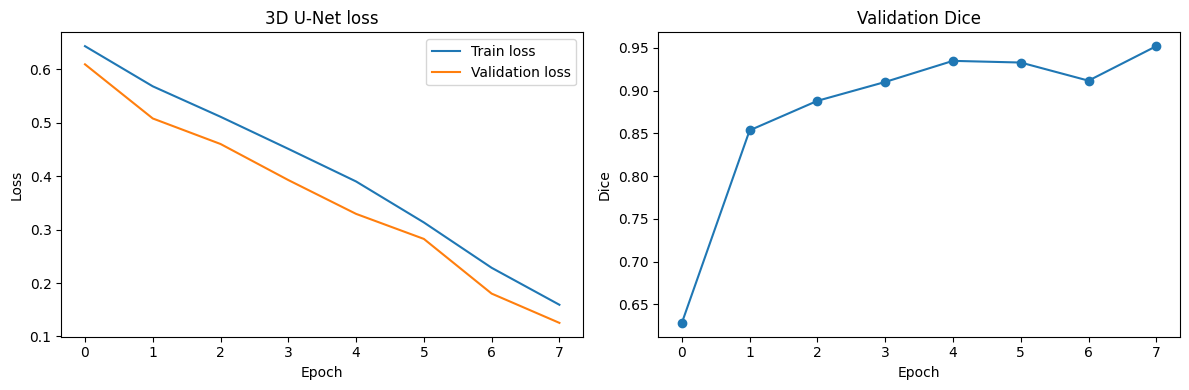

In [10]:
# ============================================================
# 9. TRAINING CURVES
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="Train loss")
axes[0].plot(history["val_loss"], label="Validation loss")
axes[0].set_title("3D U-Net loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history["val_dice"], marker="o")
axes[1].set_title("Validation Dice")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Dice")

plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# 10. TEST SET SEGMENTATION EVALUATION
# ============================================================
test_metrics = []
test_predictions = []

with torch.no_grad():
    for i, (x, y) in enumerate(test_loader):
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)

        m = binary_segmentation_metrics(logits, y)
        test_metrics.append(m)

        prob = torch.sigmoid(logits)[0,0].cpu().numpy()
        pred = (prob > 0.5).astype(np.uint8)
        test_predictions.append(pred)

seg_summary = pd.DataFrame(test_metrics)[["dice","iou","precision","recall"]].mean()

print("TEST SEGMENTATION PERFORMANCE")
print("--------------------------------")
for k, v in seg_summary.items():
    print(f"{k.capitalize():10s}: {v:.4f}")

TEST SEGMENTATION PERFORMANCE
--------------------------------
Dice      : 0.9339
Iou       : 0.8770
Precision : 0.8777
Recall    : 0.9990


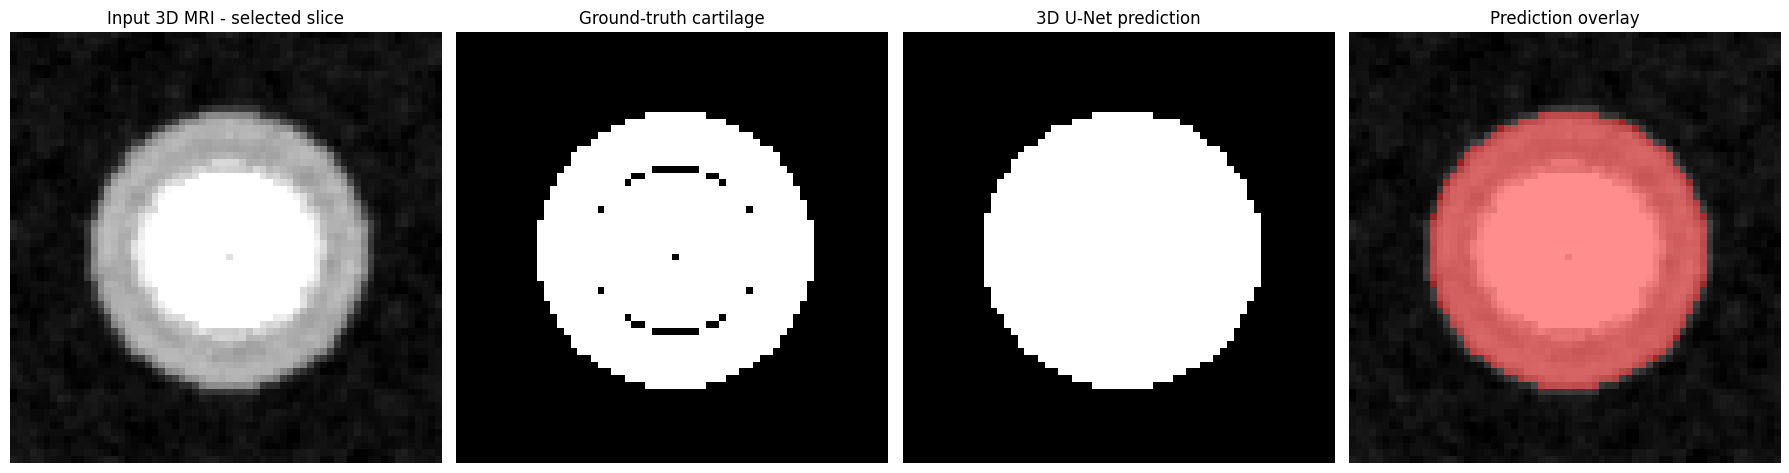

In [12]:
# ============================================================
# 11. SHOW MRI / GROUND TRUTH / PREDICTED MASK
# ============================================================
demo_case_pos = 0
real_case_id = test_ids[demo_case_pos]
case = cases[real_case_id]
pred_mask = test_predictions[demo_case_pos]

# choose the slice where predicted mask is largest
slice_idx = int(np.argmax(pred_mask.sum(axis=(1,2))))

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(case["image"][slice_idx], cmap="gray")
axes[0].set_title("Input 3D MRI - selected slice")
axes[0].axis("off")

axes[1].imshow(case["mask"][slice_idx], cmap="gray")
axes[1].set_title("Ground-truth cartilage")
axes[1].axis("off")

axes[2].imshow(pred_mask[slice_idx], cmap="gray")
axes[2].set_title("3D U-Net prediction")
axes[2].axis("off")

axes[3].imshow(case["image"][slice_idx], cmap="gray")
axes[3].imshow(
    np.ma.masked_where(pred_mask[slice_idx] == 0, pred_mask[slice_idx]),
    alpha=0.45, cmap="autumn"
)
axes[3].set_title("Prediction overlay")
axes[3].axis("off")

plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# 12. FEATURE EXTRACTION
# ============================================================
def extract_features(image, mask, age, bmi, voxel_spacing=(1.0,1.0,1.0)):
    mask = mask.astype(bool)

    voxel_volume = float(np.prod(voxel_spacing))
    target_voxels = int(mask.sum())
    volume = target_voxels * voxel_volume

    if target_voxels > 0:
        dist = ndimage.distance_transform_edt(mask, sampling=voxel_spacing)
        positive_dist = dist[mask]
        mean_thickness = float(2.0 * positive_dist.mean())
        max_thickness = float(2.0 * positive_dist.max())
        mean_intensity = float(image[mask].mean())
        std_intensity = float(image[mask].std())
    else:
        mean_thickness = 0.0
        max_thickness = 0.0
        mean_intensity = 0.0
        std_intensity = 0.0

    return {
        "target_volume": volume,
        "mean_thickness": mean_thickness,
        "max_thickness": max_thickness,
        "mean_target_intensity": mean_intensity,
        "std_target_intensity": std_intensity,
        "age": float(age),
        "bmi": float(bmi)
    }

# Run the trained segmenter on every case and build feature rows.
feature_rows = []

with torch.no_grad():
    for case_id, c in enumerate(cases):
        x = torch.from_numpy(c["image"][None,None,...]).to(DEVICE)
        logits = model(x)
        pred = (torch.sigmoid(logits)[0,0].cpu().numpy() > 0.5).astype(np.uint8)

        feats = extract_features(
            c["image"], pred, c["age"], c["bmi"]
        )
        feats["case_id"] = int(case_id)
        feats["synthetic_score"] = c["synthetic_score"]
        feats["synthetic_grade"] = c["synthetic_grade"]
        feats["true_severity_for_demo_only"] = c["severity"]
        feature_rows.append(feats)

features_df = pd.DataFrame(feature_rows)

print(features_df.head())
print("\nShape:", features_df.shape)

features_df.to_csv(f"{ARTIFACT_DIR}/demo_feature_table.csv", index=False)

   target_volume  mean_thickness  max_thickness  mean_target_intensity  \
0         4193.0        2.205635       4.000000               0.860473   
1         4270.0        2.222475       4.000000               0.857087   
2         8550.0        3.188646       8.000000               0.741889   
3         4498.0        2.276547       4.000000               0.850859   
4         2357.0        2.007732       2.828427               0.857777   

   std_target_intensity        age        bmi  case_id  synthetic_score  \
0              0.153902  71.440768  25.410214        0         2.680646   
1              0.155752  49.009158  29.477883        1         2.694229   
2              0.201800  56.096605  26.490708        2         0.575828   
3              0.158249  51.820370  28.425535        3         2.628394   
4              0.130218  71.116650  24.279951        4         3.480833   

   synthetic_grade  true_severity_for_demo_only  
0                3                     0.773956  
1   

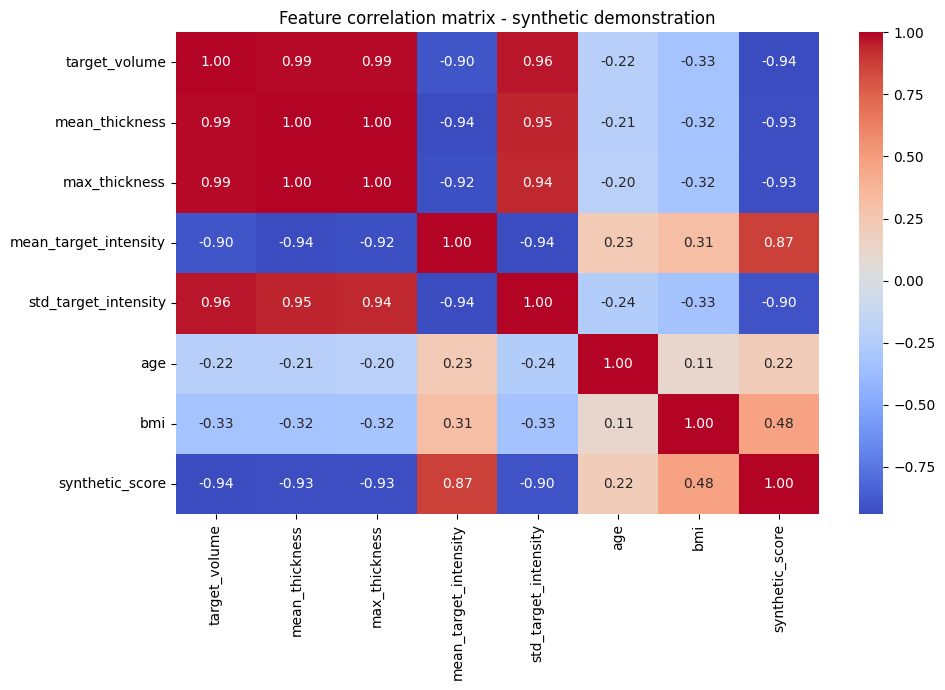

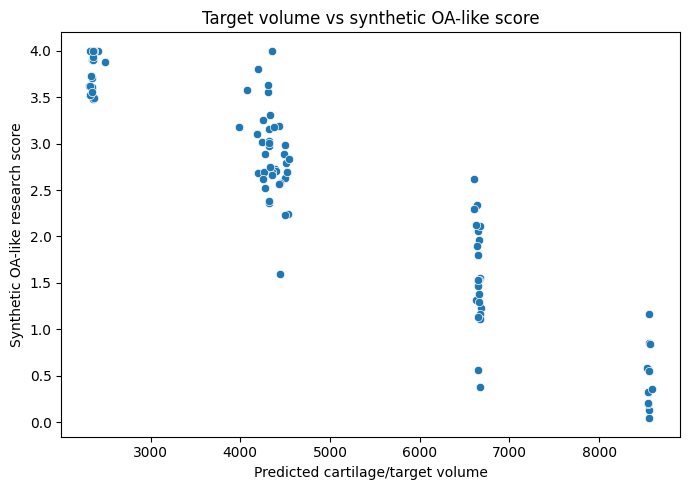

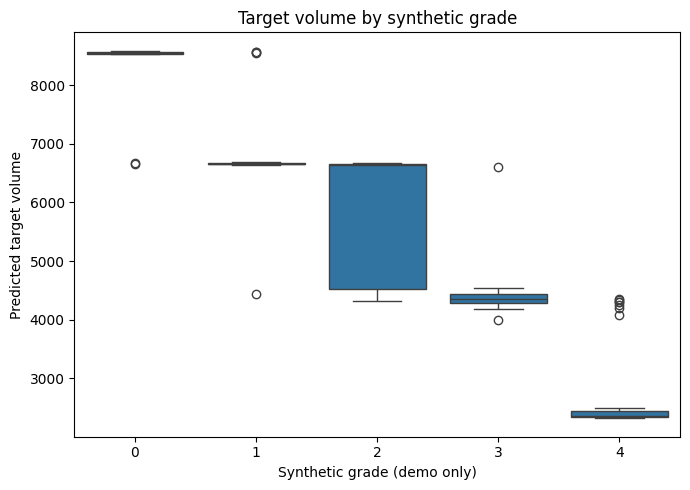

In [14]:
# ============================================================
# 13. EXPLORATORY DATA ANALYSIS
# ============================================================
numeric_cols = [
    "target_volume",
    "mean_thickness",
    "max_thickness",
    "mean_target_intensity",
    "std_target_intensity",
    "age",
    "bmi",
    "synthetic_score"
]

plt.figure(figsize=(10, 7))
sns.heatmap(features_df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature correlation matrix - synthetic demonstration")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=features_df,
    x="target_volume",
    y="synthetic_score"
)
plt.title("Target volume vs synthetic OA-like score")
plt.xlabel("Predicted cartilage/target volume")
plt.ylabel("Synthetic OA-like research score")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
sns.boxplot(
    data=features_df,
    x="synthetic_grade",
    y="target_volume"
)
plt.title("Target volume by synthetic grade")
plt.xlabel("Synthetic grade (demo only)")
plt.ylabel("Predicted target volume")
plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# 14. REGRESSION MODELS
# ============================================================
from sklearn.linear_model import LinearRegression

FEATURE_COLS = [
    "target_volume",
    "mean_thickness",
    "max_thickness",
    "mean_target_intensity",
    "std_target_intensity",
    "age",
    "bmi"
]

train_df = features_df[features_df.case_id.isin(train_ids)].copy()
val_df = features_df[features_df.case_id.isin(val_ids)].copy()
test_df = features_df[features_df.case_id.isin(test_ids)].copy()

X_train = train_df[FEATURE_COLS]
y_train = train_df["synthetic_score"]

X_val = val_df[FEATURE_COLS]
y_val = val_df["synthetic_score"]

X_test = test_df[FEATURE_COLS]
y_test = test_df["synthetic_score"]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

linear_reg = LinearRegression()
linear_reg.fit(X_train_scaled, y_train)

rf_reg = RandomForestRegressor(
    n_estimators=250,
    random_state=SEED,
    max_depth=6
)
rf_reg.fit(X_train, y_train)

models_reg = {
    "Linear Regression": (linear_reg, X_test_scaled),
    "Random Forest": (rf_reg, X_test)
}

reg_results = []

for name, (m, X_eval) in models_reg.items():
    pred = m.predict(X_eval)
    reg_results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": mean_squared_error(y_test, pred) ** 0.5,
        "R2": r2_score(y_test, pred)
    })

reg_results_df = pd.DataFrame(reg_results)
print(reg_results_df)

joblib.dump(rf_reg, f"{ARTIFACT_DIR}/demo_regressor.pkl")
joblib.dump(scaler, f"{ARTIFACT_DIR}/demo_feature_scaler.pkl")

               Model       MAE      RMSE        R2
0  Linear Regression  0.375174  0.490937  0.801813
1      Random Forest  0.377537  0.541075  0.759265


['/content/knee_oa_demo_artifacts/demo_feature_scaler.pkl']

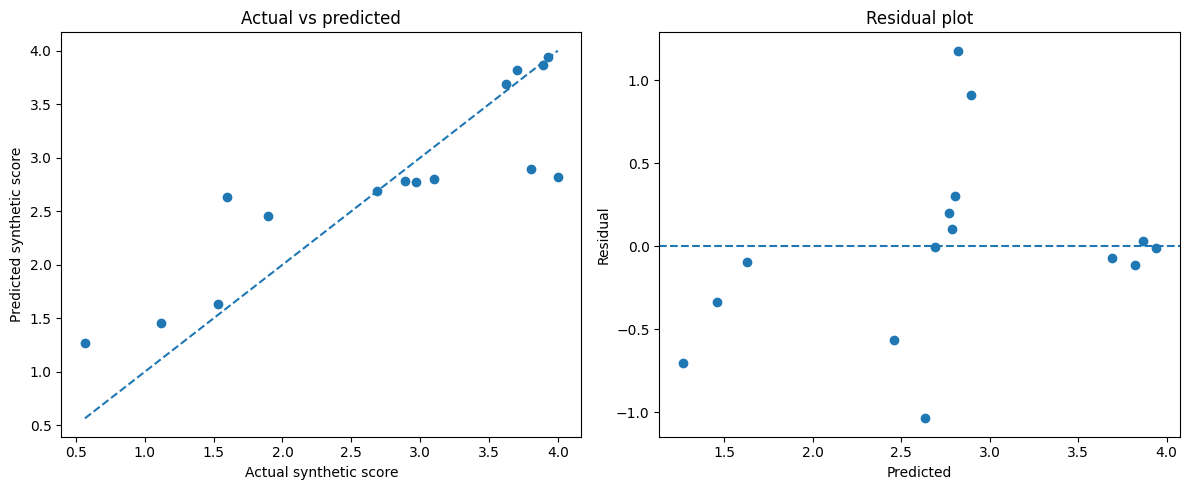

Random Forest regression:
MAE : 0.3775
RMSE: 0.5411
R²  : 0.7593


In [16]:
# ============================================================
# 15. REGRESSION VISUALIZATION
# ============================================================
best_reg = rf_reg
best_pred = best_reg.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test, best_pred)
mn = min(y_test.min(), best_pred.min())
mx = max(y_test.max(), best_pred.max())
axes[0].plot([mn, mx], [mn, mx], "--")
axes[0].set_xlabel("Actual synthetic score")
axes[0].set_ylabel("Predicted synthetic score")
axes[0].set_title("Actual vs predicted")

residuals = y_test.values - best_pred
axes[1].scatter(best_pred, residuals)
axes[1].axhline(0, linestyle="--")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residual plot")

plt.tight_layout()
plt.show()

print("Random Forest regression:")
print("MAE :", round(mean_absolute_error(y_test, best_pred), 4))
print("RMSE:", round(mean_squared_error(y_test, best_pred) ** 0.5, 4))
print("R²  :", round(r2_score(y_test, best_pred), 4))

CLASSIFICATION RESULTS - SYNTHETIC DEMO
-----------------------------------------
Accuracy              : 0.7333
Precision_macro       : 0.6476
Recall_macro          : 0.6667
F1_macro              : 0.6388
Balanced_accuracy     : 0.6667


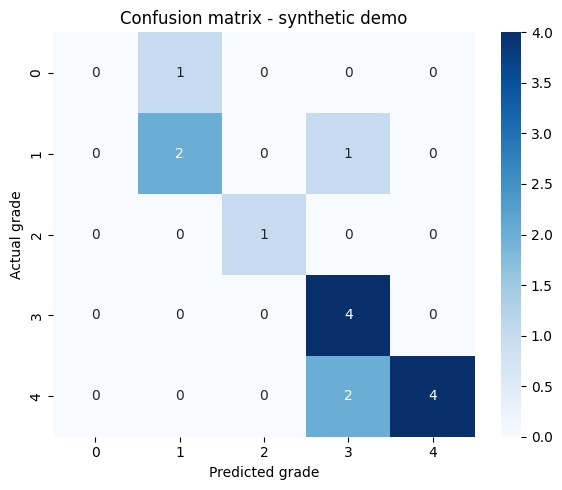

['/content/knee_oa_demo_artifacts/demo_classifier.pkl']

In [17]:
# ============================================================
# 16. CLASSIFICATION
# ============================================================
clf = RandomForestClassifier(
    n_estimators=250,
    random_state=SEED,
    max_depth=7,
    class_weight="balanced"
)
clf.fit(X_train, train_df["synthetic_grade"])

y_grade_test = test_df["synthetic_grade"]
pred_grade = clf.predict(X_test)

classification_results = {
    "Accuracy": accuracy_score(y_grade_test, pred_grade),
    "Precision_macro": precision_score(y_grade_test, pred_grade, average="macro", zero_division=0),
    "Recall_macro": recall_score(y_grade_test, pred_grade, average="macro", zero_division=0),
    "F1_macro": f1_score(y_grade_test, pred_grade, average="macro", zero_division=0),
    "Balanced_accuracy": balanced_accuracy_score(y_grade_test, pred_grade)
}

print("CLASSIFICATION RESULTS - SYNTHETIC DEMO")
print("-----------------------------------------")
for k, v in classification_results.items():
    print(f"{k:22s}: {v:.4f}")

labels_present = sorted(np.unique(np.concatenate([y_grade_test.values, pred_grade])))
cm = confusion_matrix(y_grade_test, pred_grade, labels=labels_present)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=labels_present, yticklabels=labels_present
)
plt.xlabel("Predicted grade")
plt.ylabel("Actual grade")
plt.title("Confusion matrix - synthetic demo")
plt.tight_layout()
plt.show()

joblib.dump(clf, f"{ARTIFACT_DIR}/demo_classifier.pkl")

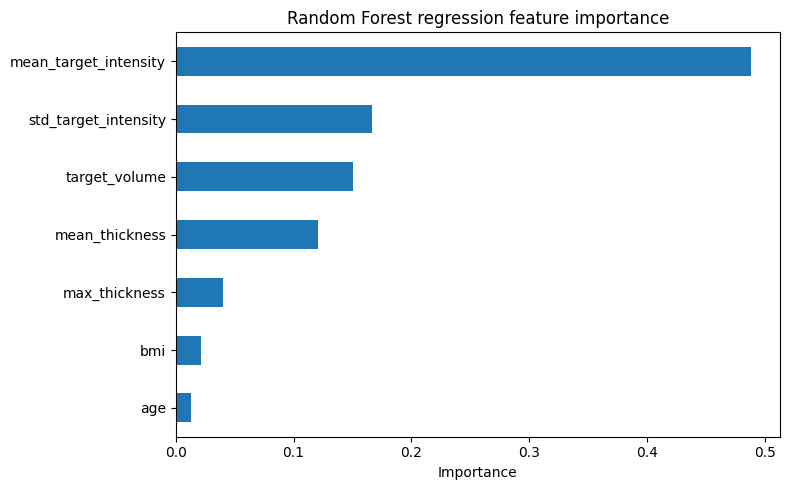

mean_target_intensity    0.488255
std_target_intensity     0.166482
target_volume            0.150539
mean_thickness           0.120703
max_thickness            0.039926
bmi                      0.021505
age                      0.012589
dtype: float64


In [18]:
# ============================================================
# 17. FEATURE IMPORTANCE
# ============================================================
importance = pd.Series(
    rf_reg.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=False)

plt.figure(figsize=(8,5))
importance.sort_values().plot(kind="barh")
plt.xlabel("Importance")
plt.title("Random Forest regression feature importance")
plt.tight_layout()
plt.show()

print(importance)

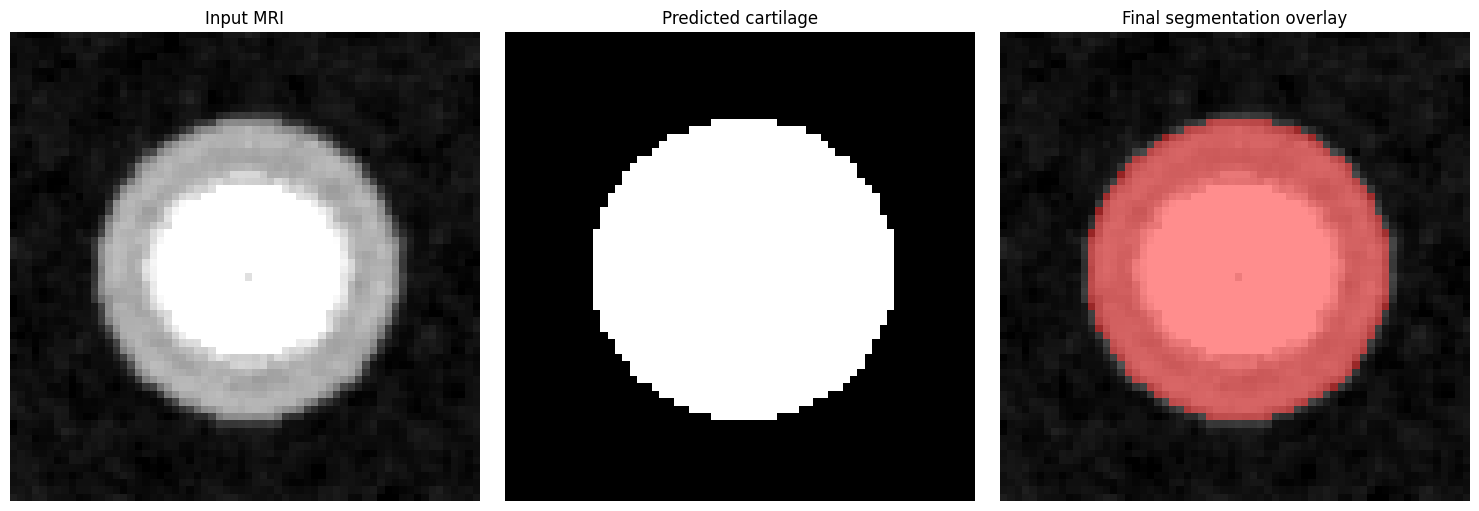

        KNEE OA AI - SHOWCASE PREDICTION
Case ID:                 41
Estimated target volume: 6664.00
Estimated thickness:     2.786
Mean target intensity:   0.752
Age:                     53.9
BMI:                     22.0
-------------------------------------------------------
Predicted research score: 1.46
Predicted research grade: 1
-------------------------------------------------------
Segmentation Dice:        0.9588
Segmentation IoU:         0.9209
DEMO ONLY: score/grade are synthetic research targets.
NOT A CLINICAL DIAGNOSIS.


In [19]:
# ============================================================
# 18. FINAL END-TO-END PREDICTION
# ============================================================
def predict_case_by_id(case_id):
    c = cases[int(case_id)]

    # 1) Segmentation
    model.eval()
    with torch.no_grad():
        x = torch.from_numpy(c["image"][None,None,...]).to(DEVICE)
        logits = model(x)
        prob = torch.sigmoid(logits)[0,0].cpu().numpy()
        pred_mask = (prob > 0.5).astype(np.uint8)

    # 2) Feature extraction
    feats = extract_features(c["image"], pred_mask, c["age"], c["bmi"])
    feature_vector = pd.DataFrame([feats])[FEATURE_COLS]

    # 3) Regression
    predicted_score = float(rf_reg.predict(feature_vector)[0])

    # 4) Classification
    predicted_grade = int(clf.predict(feature_vector)[0])

    # 5) Segmentation quality against known demo ground truth
    seg_t = torch.from_numpy(pred_mask[None,None,...]).float()
    seg_y = torch.from_numpy(c["mask"][None,None,...]).float()
    inter = (seg_t * seg_y).sum().item()
    dice = (2*inter)/(seg_t.sum().item()+seg_y.sum().item()+1e-8)
    union = ((seg_t + seg_y) > 0).sum().item()
    iou = inter/(union+1e-8)

    return {
        "case_id": int(case_id),
        "image": c["image"],
        "true_mask_demo": c["mask"],
        "pred_mask": pred_mask,
        "features": feats,
        "predicted_score": predicted_score,
        "predicted_grade": predicted_grade,
        "demo_reference_score": c["synthetic_score"],
        "demo_reference_grade": c["synthetic_grade"],
        "dice": dice,
        "iou": iou
    }

final_case_id = int(test_ids[0])
result = predict_case_by_id(final_case_id)

slice_idx = int(np.argmax(result["pred_mask"].sum(axis=(1,2))))

fig, axes = plt.subplots(1, 3, figsize=(15,5))
axes[0].imshow(result["image"][slice_idx], cmap="gray")
axes[0].set_title("Input MRI")
axes[0].axis("off")

axes[1].imshow(result["pred_mask"][slice_idx], cmap="gray")
axes[1].set_title("Predicted cartilage")
axes[1].axis("off")

axes[2].imshow(result["image"][slice_idx], cmap="gray")
axes[2].imshow(
    np.ma.masked_where(result["pred_mask"][slice_idx] == 0,
                       result["pred_mask"][slice_idx]),
    alpha=0.45, cmap="autumn"
)
axes[2].set_title("Final segmentation overlay")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print("="*55)
print("        KNEE OA AI - SHOWCASE PREDICTION")
print("="*55)
print(f"Case ID:                 {result['case_id']}")
print(f"Estimated target volume: {result['features']['target_volume']:.2f}")
print(f"Estimated thickness:     {result['features']['mean_thickness']:.3f}")
print(f"Mean target intensity:   {result['features']['mean_target_intensity']:.3f}")
print(f"Age:                     {result['features']['age']:.1f}")
print(f"BMI:                     {result['features']['bmi']:.1f}")
print("-"*55)
print(f"Predicted research score: {result['predicted_score']:.2f}")
print(f"Predicted research grade: {result['predicted_grade']}")
print("-"*55)
print(f"Segmentation Dice:        {result['dice']:.4f}")
print(f"Segmentation IoU:         {result['iou']:.4f}")
print("="*55)
print("DEMO ONLY: score/grade are synthetic research targets.")
print("NOT A CLINICAL DIAGNOSIS.")

In [20]:
# ============================================================
# 19. SAVE A FINAL DEMO REPORT
# ============================================================
report = {
    "mode": "synthetic_proof_of_concept",
    "volume_shape": VOLUME_SHAPE,
    "n_samples": N_SAMPLES,
    "segmentation_metrics": seg_summary.to_dict(),
    "regression_results": reg_results_df.to_dict(orient="records"),
    "classification_results": classification_results,
    "final_case": {
        "case_id": result["case_id"],
        "predicted_score": result["predicted_score"],
        "predicted_grade": result["predicted_grade"],
        "dice": result["dice"],
        "iou": result["iou"]
    }
}

with open(f"{ARTIFACT_DIR}/demo_report.json", "w") as f:
    json.dump(report, f, indent=2)

print("Saved artifacts:")
for name in sorted(os.listdir(ARTIFACT_DIR)):
    print(" -", name)

Saved artifacts:
 - demo_3d_unet_best.pth
 - demo_classifier.pkl
 - demo_feature_scaler.pkl
 - demo_feature_table.csv
 - demo_regressor.pkl
 - demo_report.json


Real MRI loaded.
Shape: (256, 256, 20)
Voxel spacing: (np.float32(0.3030303), np.float32(0.3030303), np.float32(4.5))


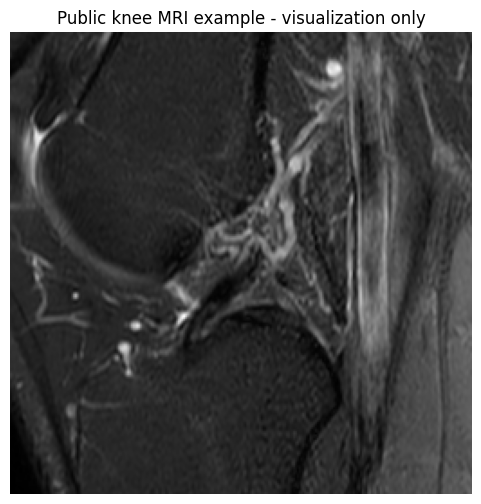

In [21]:
# ============================================================
# 20. OPTIONAL REAL MRI VISUALIZATION ONLY
# ============================================================
# The public SA-INR repository documents a knee MRI test volume at:
#
# Run this cell only if you have internet access in Colab.

REAL_MRI_URL = "https://raw.githubusercontent.com/XinWang-99/SA-INR/main/test/knee.nii.gz"
REAL_MRI_PATH = "/content/real_knee_demo.nii.gz"

try:
    import requests
    r = requests.get(REAL_MRI_URL, timeout=30)
    r.raise_for_status()
    with open(REAL_MRI_PATH, "wb") as f:
        f.write(r.content)

    import nibabel as nib
    nii = nib.load(REAL_MRI_PATH)
    real_vol = nii.get_fdata()
    print("Real MRI loaded.")
    print("Shape:", real_vol.shape)
    print("Voxel spacing:", nii.header.get_zooms()[:3])

    # Select middle/central slice for display.
    if real_vol.ndim == 3:
        s = real_vol.shape[2] // 2
        plt.figure(figsize=(6,6))
        plt.imshow(real_vol[:,:,s].T, cmap="gray", origin="lower")
        plt.title("Public knee MRI example - visualization only")
        plt.axis("off")
        plt.show()
except Exception as e:
    print("Optional real-MRI download/visualization failed:", e)
    print("You can manually upload any authorized NIfTI knee MRI instead.")